# House Price Prediction using Machine Learning
**Synent Technologies Data Science Internship | Task 8**
**Candidate:** Hit Goyani | **ID:** SYN/M2/IP1050
**Objective:** Predict California median house prices using
regression models. Compare Linear Regression (baseline)
vs Random Forest Regressor (final model).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
print('Libraries imported successfully')

Libraries imported successfully


In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print('Dataset loaded successfully')
print('Shape:', df.shape)
print('Rows:', len(df))
print('Columns:', df.columns.tolist())
df.head()

Dataset loaded successfully
Shape: (20640, 9)
Rows: 20640
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/california_housing.csv', index=False)
print('Dataset exported to data/california_housing.csv')
print('Total records exported:', len(df))

Dataset exported to data/california_housing.csv
Total records exported: 20640


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== DUPLICATE ROWS ===')
print('Duplicates:', df.duplicated().sum())
print()
print('=== CONCLUSION ===')
print('California Housing Dataset requires no cleaning.')
print('No missing values, no duplicates.')
print('This is a clean, well-maintained sklearn dataset.')

=== MISSING VALUES ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates: 0

=== CONCLUSION ===
California Housing Dataset requires no cleaning.
No missing values, no duplicates.
This is a clean, well-maintained sklearn dataset.


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Important: Target Variable

`MedHouseVal` is the median house value measured in
**units of $100,000**. A value of 2.5 means $250,000.

**Known Dataset Limitation:**
Values above $500,000 are capped at exactly $500,001
in this dataset. This artificial ceiling introduces a
visible residual cluster at the upper end of the price
distribution. This is a dataset limitation, not a model
deficiency, and should be acknowledged in result
interpretation.

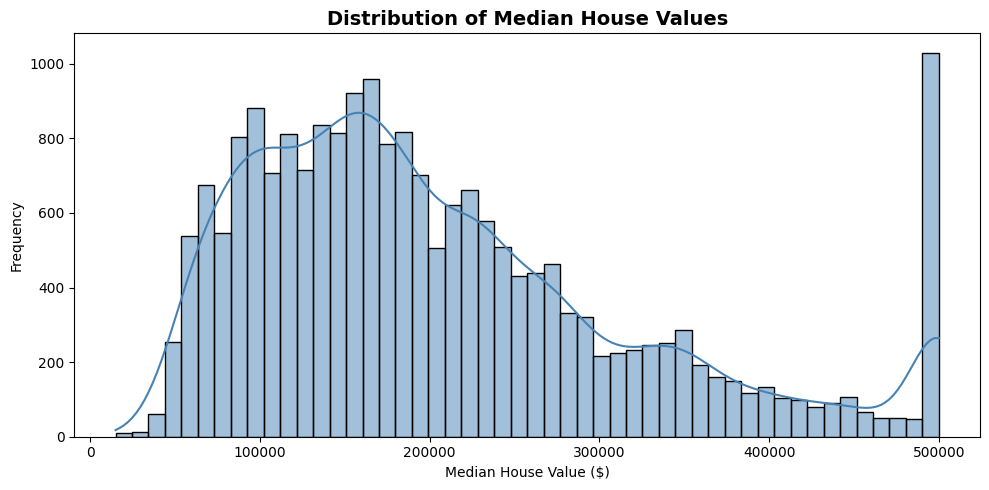

Mean   : $206,856
Median : $179,700
Max    : $500,001
Min    : $14,999


In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MedHouseVal'] * 100000,
             bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Values',
          fontsize=14, fontweight='bold')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/target_distribution.png', dpi=150)
plt.show()

print(f"Mean   : ${df['MedHouseVal'].mean()*100000:,.0f}")
print(f"Median : ${df['MedHouseVal'].median()*100000:,.0f}")
print(f"Max    : ${df['MedHouseVal'].max()*100000:,.0f}")
print(f"Min    : ${df['MedHouseVal'].min()*100000:,.0f}")

In [8]:
df['rooms_per_bedrooms'] = df['AveRooms'] / df['AveBedrms']

# Why: AveRooms and AveBedrms individually are averages
# per household. Their ratio captures housing spaciousness
# more meaningfully. A high ratio = more living space per
# bedroom = higher expected property value.

print('Feature engineered: rooms_per_bedrooms')
print('New shape:', df.shape)
df[['AveRooms', 'AveBedrms', 'rooms_per_bedrooms']].describe()

Feature engineered: rooms_per_bedrooms
New shape: (20640, 10)


,AveRooms,AveBedrms,rooms_per_bedrooms
count,20640.000000,20640.000000,20640.000000
mean,5.429000,1.096675,4.984262
std,2.474173,0.473911,1.171836
min,0.846154,0.333333,1.000000
25%,4.440716,1.006079,4.169542
50%,5.229129,1.048780,4.921728
75%,6.052381,1.099526,5.700424
max,141.909091,34.066667,10.000000


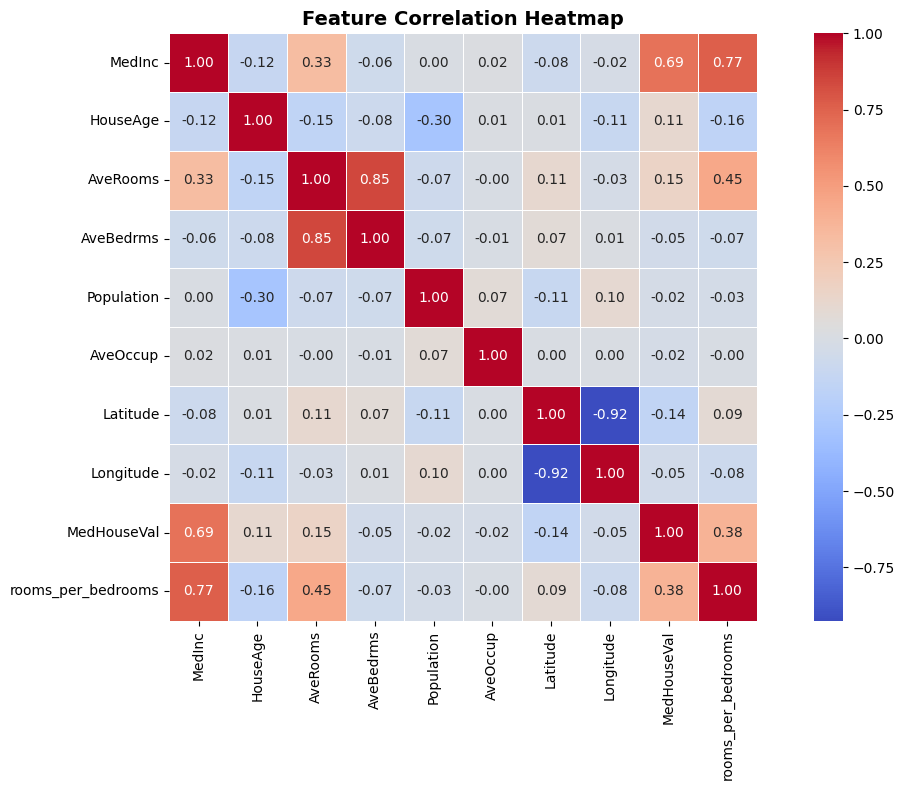

In [9]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
FEATURE_COLS = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude',
                'rooms_per_bedrooms']

X = df[FEATURE_COLS]
y = df['MedHouseVal']

print('Features:', FEATURE_COLS)
print('Target: MedHouseVal')
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_bedrooms']
Target: MedHouseVal
X shape: (20640, 9)
y shape: (20640,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)

Training set: (16512, 9)
Testing set : (4128, 9)


In [12]:
# StandardScaler applied ONLY for Linear Regression.
# Linear Regression is sensitive to feature scale.
# Random Forest is scale-invariant and does NOT need scaling.

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_mae  = round(mean_absolute_error(y_test, lr_pred) * 100000, 2)
lr_rmse = round(np.sqrt(mean_squared_error(y_test, lr_pred))
                * 100000, 2)
lr_r2   = round(r2_score(y_test, lr_pred), 4)

print('Linear Regression (Baseline):')
print(f'  MAE  : ${lr_mae:,.2f}')
print(f'  RMSE : ${lr_rmse:,.2f}')
print(f'  R²   : {lr_r2}')

Linear Regression (Baseline):
  MAE  : $52,885.19
  RMSE : $72,802.91
  R²   : 0.5955


In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, None]
}
# 4 combinations × 5 folds = 20 fits. Runtime ~3-4 min.

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print('Best Parameters:', rf_search.best_params_)
print('Best CV R²     :', round(rf_search.best_score_, 4))

rf_pred = best_rf.predict(X_test)

rf_mae  = round(mean_absolute_error(y_test, rf_pred) * 100000, 2)
rf_rmse = round(np.sqrt(mean_squared_error(y_test, rf_pred))
                * 100000, 2)
rf_r2   = round(r2_score(y_test, rf_pred), 4)

print()
print('Random Forest Results:')
print(f'  MAE  : ${rf_mae:,.2f}')
print(f'  RMSE : ${rf_rmse:,.2f}')
print(f'  R²   : {rf_r2}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV R²     : 0.8042

Random Forest Results:
  MAE  : $32,701.06
  RMSE : $50,398.92
  R²   : 0.8062


In [14]:
comparison = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest'],
    'MAE ($)':  [lr_mae,  rf_mae],
    'RMSE ($)': [lr_rmse, rf_rmse],
    'R²':       [lr_r2,   rf_r2]
})
print(comparison.to_string(index=False))
print()

# Dynamic winner — does not hardcode RF as winner
if rf_r2 > lr_r2:
    best_model = best_rf
    best_pred  = rf_pred
    best_mae   = rf_mae
    best_rmse  = rf_rmse
    best_r2    = rf_r2
    winner     = 'Random Forest Regressor'
else:
    best_model = lr_pipeline
    best_pred  = lr_pred
    best_mae   = lr_mae
    best_rmse  = lr_rmse
    best_r2    = lr_r2
    winner     = 'Linear Regression'

print(f'Winner: {winner}')

            Model  MAE ($)  RMSE ($)     R²
Linear Regression 52885.19  72802.91 0.5955
    Random Forest 32701.06  50398.92 0.8062

Winner: Random Forest Regressor


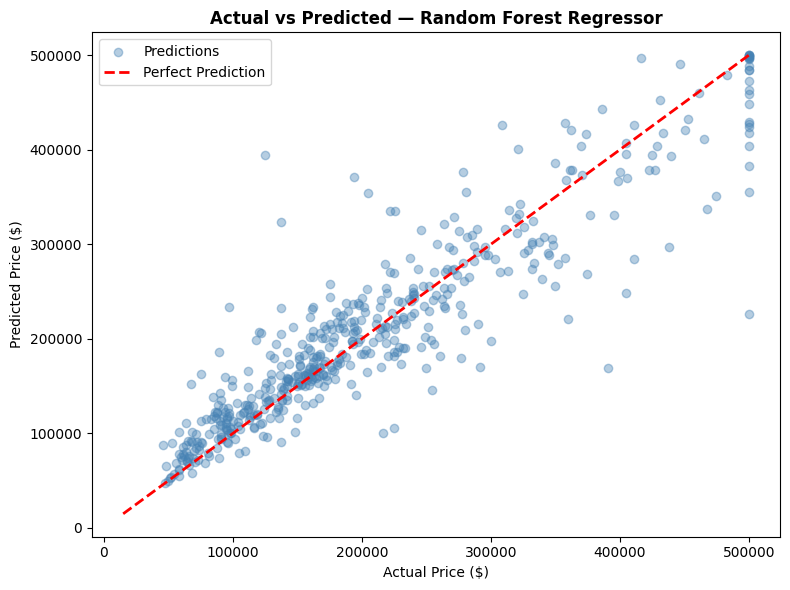

In [15]:
y_reset = y_test.reset_index(drop=True)
pred_series = pd.Series(best_pred).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.scatter(y_reset[:500] * 100000,
            pred_series[:500] * 100000,
            alpha=0.4, color='steelblue', label='Predictions')

min_val = float(y_reset.min() * 100000)
max_val = float(y_reset.max() * 100000)
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted — {winner}',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../images/actual_vs_predicted.png', dpi=150)
plt.show()

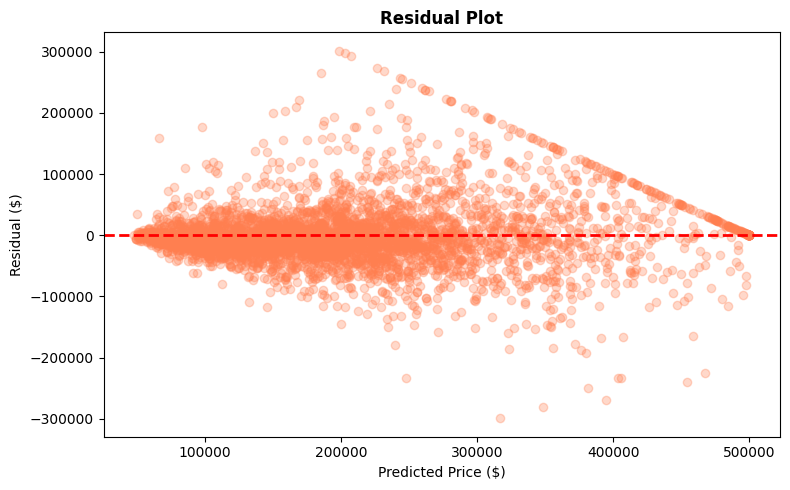

In [16]:
residuals = y_reset - pred_series

plt.figure(figsize=(8, 5))
plt.scatter(pred_series * 100000, residuals * 100000,
            alpha=0.3, color='coral')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residual Plot', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/residual_plot.png', dpi=150)
plt.show()

# Residual Interpretation:
# Points randomly scattered around zero → model errors are
# unbiased and well-distributed.
# The visible cluster at the upper end (near $500,000)
# is caused by the dataset's known $500,001 price cap —
# this is a data limitation, not a model problem.

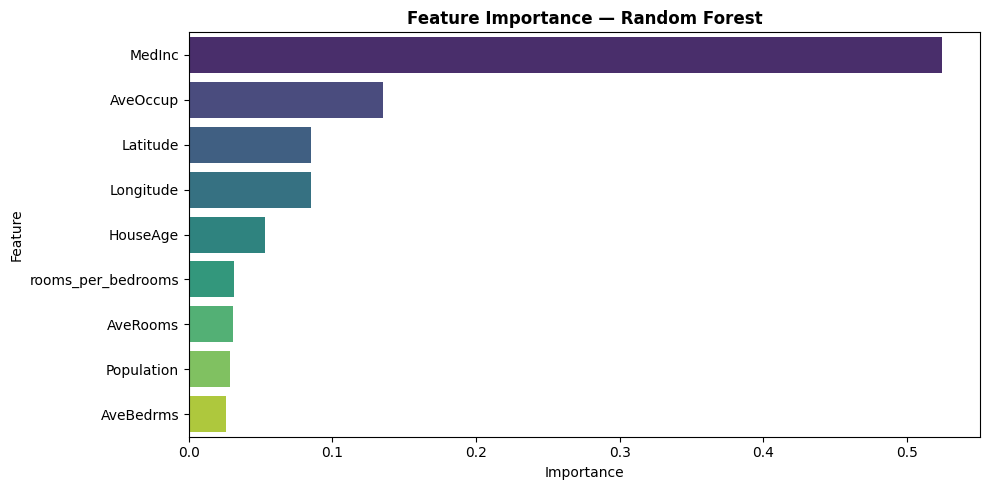

           Feature  Importance
            MedInc    0.524684
          AveOccup    0.135361
          Latitude    0.085100
         Longitude    0.085082
          HouseAge    0.053320
rooms_per_bedrooms    0.031384
          AveRooms    0.031051
        Population    0.028444
         AveBedrms    0.025574

Most important feature: MedInc


In [17]:
# Always generates this chart regardless of which model wins.
# RF: uses feature_importances_
# LR: uses absolute coefficient values (after scaling)

if winner == 'Random Forest Regressor':
    importances = best_rf.feature_importances_
    importance_title = 'Feature Importance — Random Forest'
else:
    importances = np.abs(
        lr_pipeline.named_steps['model'].coef_
    )
    importance_title = 'Feature Coefficients — Linear Regression'

feat_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feat_df, palette='viridis')
plt.title(importance_title, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

print(feat_df.to_string(index=False))
print()
print(f'Most important feature: {feat_df.iloc[0]["Feature"]}')

In [18]:
os.makedirs('../model', exist_ok=True)

joblib.dump(best_model, '../model/model.pkl')
print(f'{winner} saved as model.pkl')

model_info = {
    'dataset':        'California Housing (sklearn)',
    'total_records':  len(df),
    'features_used':  FEATURE_COLS,
    'feature_engineered': 'rooms_per_bedrooms = AveRooms / AveBedrms',
    'target':         'MedHouseVal (multiply by 100000 for USD)',
    'best_model':     winner,
    'best_params':    (rf_search.best_params_
                       if winner == 'Random Forest Regressor'
                       else 'N/A — Pipeline with StandardScaler'),
    'MAE_USD':        best_mae,
    'RMSE_USD':       best_rmse,
    'R2_score':       best_r2,
    'random_state':   RANDOM_STATE,
    'test_size':      0.2
}

with open('../model/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print('model_info.json saved')

Random Forest Regressor saved as model.pkl
model_info.json saved


In [19]:
os.makedirs('../outputs', exist_ok=True)

predictions_df = pd.DataFrame({
    'Actual_USD':    (y_reset * 100000).round(0).astype(int),
    'Predicted_USD': (pred_series * 100000).round(0).astype(int),
    'Residual_USD':  (residuals * 100000).round(0).astype(int)
})

predictions_df.to_csv('../outputs/predictions.csv', index=False)
print('predictions.csv saved')
print(f'Total predictions exported: {len(predictions_df)}')
print(predictions_df.head())

predictions.csv saved
Total predictions exported: 4128
   Actual_USD  Predicted_USD  Residual_USD
0       47700          47952          -252
1       45800          87308        -41508
2      500001         488752         11249
3      218600         254007        -35407
4      278000         226318         51682


In [20]:
print('=== KEY INSIGHTS ===')
print()
print(f'1. {winner} outperformed the baseline model')
print(f'   Best R² = {best_r2}')
print()
print(f'2. Model predicts within ${best_mae:,.0f} on average (MAE)')
print()
print(f'3. Top predictor: {feat_df.iloc[0]["Feature"]}')
print()
print('4. StandardScaler applied only to Linear Regression.')
print('   Random Forest is scale-invariant — no scaling needed.')
print()
print('5. rooms_per_bedrooms engineered feature captures')
print('   housing spaciousness beyond raw room counts.')
print()
print('6. Dataset price cap at $500,001 causes residual')
print('   clustering at upper price range — dataset limitation.')

=== KEY INSIGHTS ===

1. Random Forest Regressor outperformed the baseline model
   Best R² = 0.8062

2. Model predicts within $32,701 on average (MAE)

3. Top predictor: MedInc

4. StandardScaler applied only to Linear Regression.
   Random Forest is scale-invariant — no scaling needed.

5. rooms_per_bedrooms engineered feature captures
   housing spaciousness beyond raw room counts.

6. Dataset price cap at $500,001 causes residual
   clustering at upper price range — dataset limitation.


In [21]:
print('=== COPY THESE VALUES INTO README.md ===')
print()
print(f'| Linear Regression | ${lr_mae:,.0f} | ${lr_rmse:,.0f} | {lr_r2} |')
print(f'| Random Forest     | ${rf_mae:,.0f} | ${rf_rmse:,.0f} | {rf_r2} |')
print()
print(f'Dataset Records: {len(df)}')
print(f'Winner: {winner}')
print(f'Top Predictor: {feat_df.iloc[0]["Feature"]}')
print(f'Best MAE: {best_mae:,.0f}')


=== COPY THESE VALUES INTO README.md ===

| Linear Regression | $52,885 | $72,803 | 0.5955 |
| Random Forest     | $32,701 | $50,399 | 0.8062 |

Dataset Records: 20640
Winner: Random Forest Regressor
Top Predictor: MedInc
Best MAE: 32,701
